In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nba_api
import time
import os
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import teams

In [8]:
type('000') == str

True

In [2]:

# Function to get team ID
def get_team_id(team_name):
    all_teams = teams.get_teams()
    for team in all_teams:
        if team_name.lower() in team['full_name'].lower():
            return team['id']
    return None

# Function to get team shot data for a specific game
def get_team_shots(team_name, game_id, season_type_all_star):
    team_id = get_team_id(team_name)
    if not team_id:
        print("Team not found.")
        return None

    # Delay to avoid rate limits
    time.sleep(1)

    shot_chart = shotchartdetail.ShotChartDetail(
        team_id=team_id,
        player_id=0,  # 0 means all players on the team
        game_id_nullable=game_id,
        context_measure_simple='FGA',
        season_type_all_star=season_type_all_star
    )

    df = shot_chart.get_data_frames()
    return df


In [3]:
get_team_id('Los Angeles Lakers')

1610612747

In [17]:

df = get_team_shots('Minnesota Timberwolves', '0042400161', season_type_all_star='Playoffs')  # Replace with actual GAME_ID



In [110]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc

# Draw basketball half court
def draw_court(ax=None, color='black', lw=2):
    if ax is None:
        ax = plt.gca()

    # Hoop
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    
    # Backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    
    # Paint
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    
    # Free throw top arc
    top_arc = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    
    # Free throw bottom arc
    bottom_arc = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linestyle='dashed', linewidth=lw, color=color)
    
    # Restricted area
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    
    # 3PT line
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    
    # Center court circle (not needed for halfcourt)

    court_elements = [hoop, backboard, outer_box, inner_box, top_arc, bottom_arc,
                      restricted, corner_three_a, corner_three_b, three_arc]
    
    for element in court_elements:
        ax.add_patch(element)

    return ax

# Function to plot team shots
def plot_team_shots(shots_df, team_name, game_id, color_by='Make', zone_colors=None):
    plt.figure(figsize=(12, 11))
    ax = plt.gca()
    draw_court(ax)

    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    ax.set_title(f"{team_name} Shot Chart - Game ID {game_id}", fontsize=15)

    if color_by == 'Make':
        made = shots_df[shots_df['SHOT_MADE_FLAG'] == 1]
        missed = shots_df[shots_df['SHOT_MADE_FLAG'] == 0]

        ax.scatter(made['LOC_X'], made['LOC_Y'], c='green', label='Made Shot', s=100, edgecolors='black')
        ax.scatter(missed['LOC_X'], missed['LOC_Y'], c='red', label='Missed Shot', s=100, edgecolors='black', alpha=0.6)

    elif color_by == 'SHOT_ZONE_BASIC':
        unique_zones = shots_df['SHOT_ZONE_BASIC'].unique()
        
        if zone_colors is None:
            # Default to tab10 colors if not provided
            cmap = plt.get_cmap('tab10')
            zone_colors = {zone: cmap(i % 10) for i, zone in enumerate(unique_zones)}

        for zone in unique_zones:
            zone_df = shots_df[shots_df['SHOT_ZONE_BASIC'] == zone]
            color = zone_colors.get(zone, '#777777')  # fallback color if not specified
            ax.scatter(zone_df['LOC_X'], zone_df['LOC_Y'],
                       c=color, label=zone, s=100, edgecolors='black', alpha=0.75)

        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

    else:
        raise ValueError("color_by must be either 'Make' or 'SHOT_ZONE_BASIC'")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#f0f0f0')
    plt.tight_layout()
    plt.savefig(f"ad_hoc/{team_name}_shots_{game_id}_{color_by}.png", dpi=300)
    plt.show()


In [23]:
min_shots = df[0]


In [50]:
min_shots['SHOT_ZONE_BASIC'].value_counts()

SHOT_ZONE_BASIC
Above the Break 3        30
Restricted Area          24
In The Paint (Non-RA)    16
Right Corner 3            7
Left Corner 3             5
Mid-Range                 4
Name: count, dtype: int64

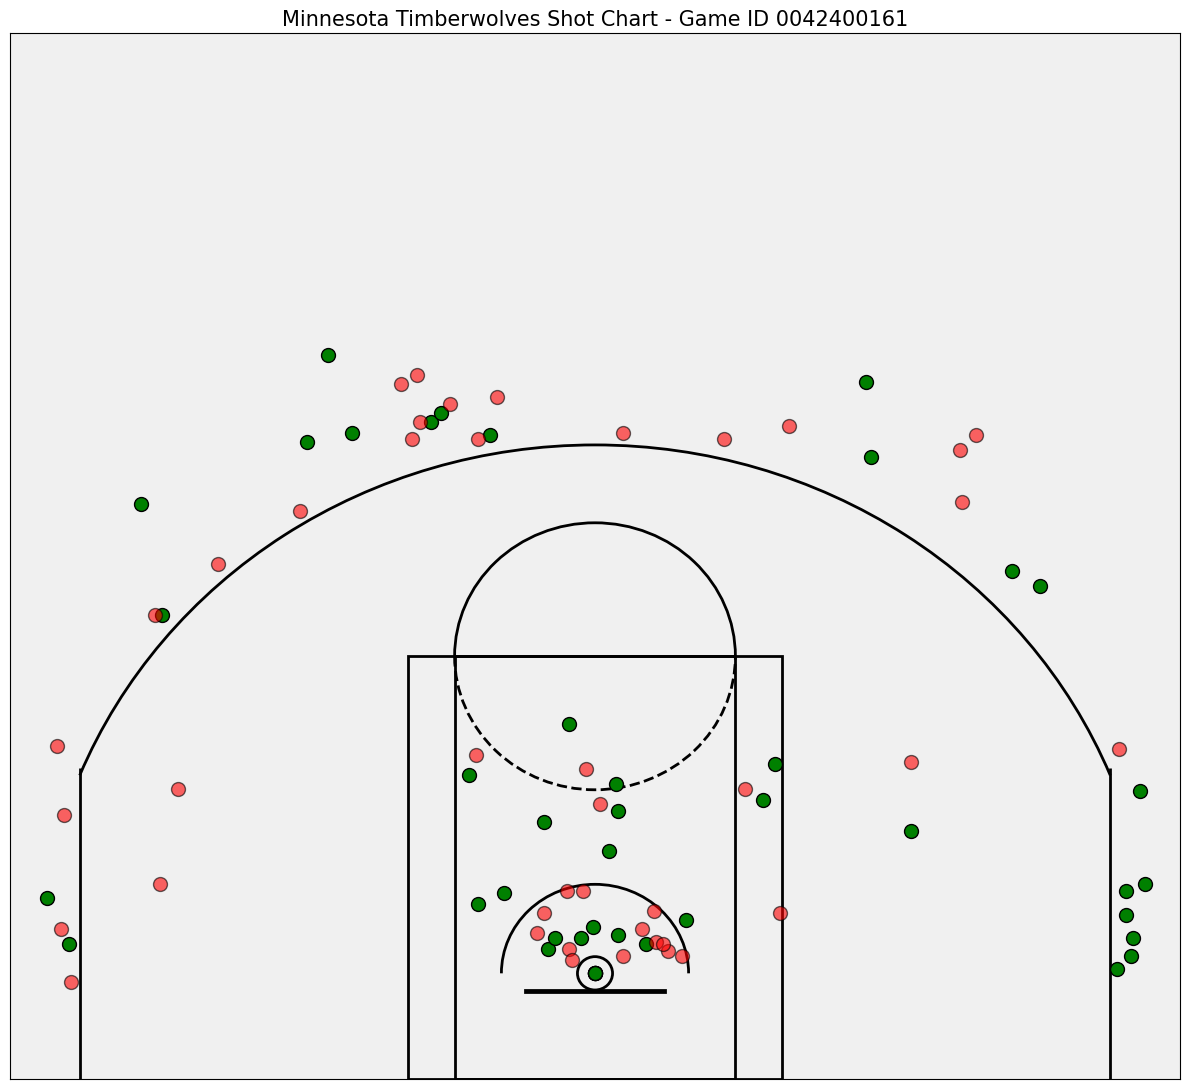

In [111]:
if not min_shots.empty:
    plot_team_shots(min_shots, 'Minnesota Timberwolves', '0042400161')
else:
    print("No shots found for that game.")

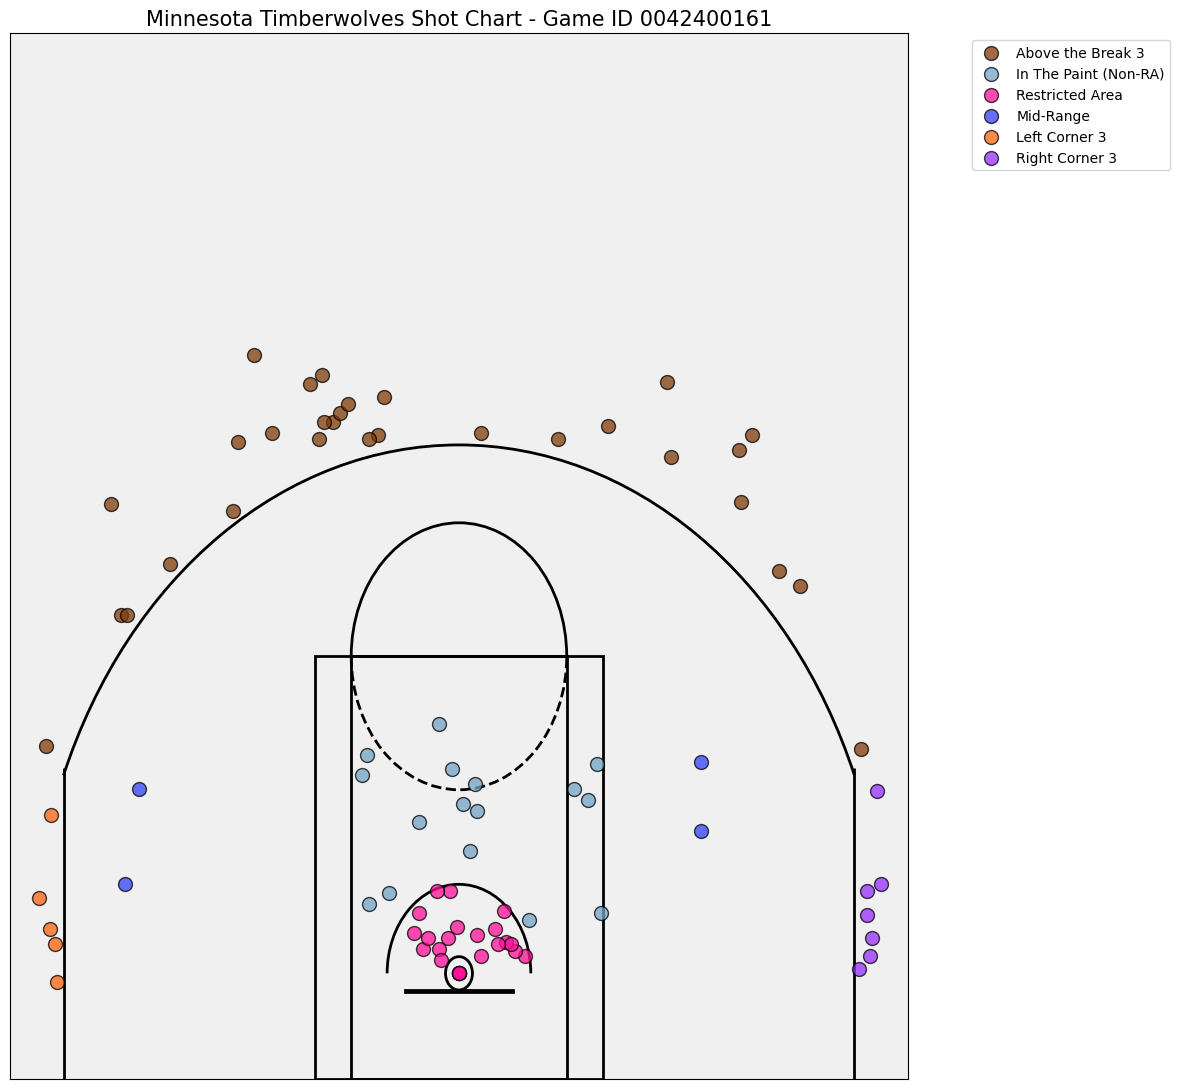

In [105]:
custom_colors = {
    'Restricted Area': '#ff1099',
    'In The Paint (Non-RA)': '#73a2c6',
    'Mid-Range': '#3241f9',
    'Left Corner 3': '#fc630f',
    'Right Corner 3': '#952fff',
    'Above the Break 3': '#7f3b08',
    'Backcourt': '#999999'
}
if not min_shots.empty:
    plot_team_shots(min_shots, 'Minnesota Timberwolves', '0042400161', color_by = 'SHOT_ZONE_BASIC', zone_colors= custom_colors)
else:
    print("No shots found for that game.")

In [52]:
shot_breakdown = min_shots[['SHOT_ZONE_BASIC', 'SHOT_MADE_FLAG', 'SHOT_ATTEMPTED_FLAG']].groupby(['SHOT_ZONE_BASIC']).sum()

In [67]:
shot_breakdown['FG%'] = shot_breakdown['SHOT_MADE_FLAG']/shot_breakdown['SHOT_ATTEMPTED_FLAG']
shot_breakdown = shot_breakdown.rename(columns={'SHOT_MADE_FLAG': 'FGM', 'SHOT_ATTEMPTED_FLAG': 'FGA'})

In [ ]:
bruh = get_team_shots('Minnesota Timberwolves', '0022400952', season_type_all_star='Regular Season')  # Replace with actual GAME_ID

In [78]:
league_shot_breakdown = bruh[1][['SHOT_ZONE_BASIC', 'FGA', 'FGM']].groupby('SHOT_ZONE_BASIC').sum()
league_shot_breakdown['FG%'] = league_shot_breakdown['FGM'] / league_shot_breakdown['FGA']

In [109]:
league_shot_breakdown2_3 = league_shot_breakdown.groupby()

,FGA,FGM,FG%
SHOT_ZONE_BASIC,,,
Above the Break 3,68358,24143,0.353185
Backcourt,517,12,0.023211
In The Paint (Non-RA),44475,19734,0.443710
Left Corner 3,12188,4706,0.386117
Mid-Range,21402,8925,0.417017
Restricted Area,61190,40603,0.663556
Right Corner 3,11397,4443,0.389839


In [79]:
shots = pd.merge(shot_breakdown, league_shot_breakdown, how = 'inner', on = 'SHOT_ZONE_BASIC',suffixes=('_MIN', '_League'))

In [82]:
shots['FGA_%_of_tot_MIN'] = shots['FGA_MIN'] / shots['FGA_MIN'].sum()
shots['FGA_%_of_tot_League'] = shots['FGA_League'] / shots['FGA_League'].sum()

In [84]:
shots['FG%_difference'] = shots['FG%_MIN'] - shots['FG%_League']

In [87]:
shots.to_csv('ad_hoc/MIN_shots_game1.csv')